# 05. SASRec — Self-Attentive Sequential Recommendation

논문: *Kang & McAuley, "Self-Attentive Sequential Recommendation" (ICDM 2018)*

## MF/NCF의 남은 한계

```
유저 A의 이력: 기초 크림 → 수분 토너 → 고보습 세럼

MF/NCF 입력: {기초 크림, 수분 토너, 고보습 세럼}  ← 집합(순서 없음)
SASRec 입력: [기초 크림, 수분 토너, 고보습 세럼]  ← 시퀀스(순서 있음)
```

MF/NCF는 유저의 전체 이력을 **하나의 정적 벡터**로 압축합니다.  
SASRec은 각 위치의 **컨텍스트**를 Transformer로 별도 학습해 다음 아이템을 예측합니다.

## 아키텍처

```
[pad, pad, item₁, item₂, item₃]   ← 입력 시퀀스 (왼쪽 패딩)
          ↓         ↓         ↓
    item_emb + pos_emb 합산
          ↓
  ┌─── Transformer Block × N ───┐
  │  LayerNorm                  │
  │  Causal Self-Attention      │  ← 미래 위치를 마스킹
  │  Residual                   │
  │  LayerNorm                  │
  │  Feed-Forward (GELU)        │
  │  Residual                   │
  └─────────────────────────────┘
          ↓         ↓         ↓
     h₁         h₂         h₃     ← 각 위치의 컨텍스트 표현
                            ↓
              item₄ 예측 (next-item)
```

In [1]:
import sys
sys.path.append('..')

import json
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from pathlib import Path

from models.mf import MatrixFactorization, BPRDataset
from models.ncf import NeuMF
from models.sasrec import SASRec, SASRecDataset
from models.evaluate import evaluate
from scripts.train import make_sasrec_score_fn

DATA_DIR = Path('../data/processed/All_Beauty')
train_df = pd.read_parquet(DATA_DIR / 'train.parquet')
test_df  = pd.read_parquet(DATA_DIR / 'test.parquet')
with open(DATA_DIR / 'dataset_meta.json') as f:
    meta = json.load(f)

n_users, n_items = meta['n_users'], meta['n_items']
MAX_LEN = 50

## 1. Causal Self-Attention — 핵심 원리

SASRec의 가장 중요한 설계: **미래 위치를 볼 수 없다.**

```
Attention 행렬 (5×5 시퀀스):

        key₀  key₁  key₂  key₃  key₄
query₀ [  ✓    ✗     ✗     ✗     ✗  ]  ← 위치 0은 자신만 참조
query₁ [  ✓    ✓     ✗     ✗     ✗  ]  ← 위치 1은 0,1 참조
query₂ [  ✓    ✓     ✓     ✗     ✗  ]
query₃ [  ✓    ✓     ✓     ✓     ✗  ]
query₄ [  ✓    ✓     ✓     ✓     ✓  ]  ← 마지막 위치로 다음 아이템 예측
```

왜 미래를 차단하는가?  
훈련 중 "item₄ 예측" 위치가 item₄를 보면 정답을 그냥 외워버림 (data leakage).

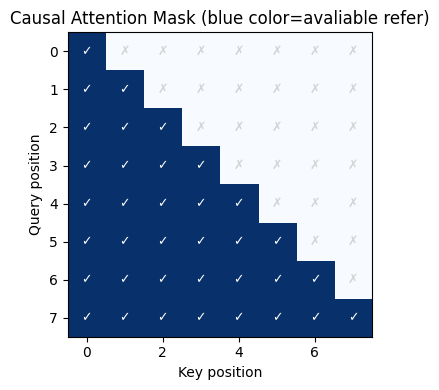

In [2]:
# Causal mask 시각화
L = 8
causal_mask = torch.tril(torch.ones(L, L)).numpy()  # 1 = 참조 가능

plt.figure(figsize=(5, 4))
plt.imshow(causal_mask, cmap='Blues', vmin=0, vmax=1)
plt.title('Causal Attention Mask (blue color=avaliable refer)')
plt.xlabel('Key position')
plt.ylabel('Query position')
for i in range(L):
    for j in range(L):
        plt.text(j, i, '✓' if causal_mask[i, j] else '✗',
                 ha='center', va='center', fontsize=9,
                 color='white' if causal_mask[i, j] else 'lightgray')
plt.tight_layout()
plt.show()

## 2. 데이터 형태 비교: MF vs SASRec

In [3]:
# MF/NCF 데이터: 개별 (user, item) 쌍
bpr_dataset = BPRDataset(train_df, n_items)
u, pos, neg = bpr_dataset[0]
print("=== MF/NCF 입력 (BPRDataset) ===")
print(f"  user_id  : {u.item()}")
print(f"  pos_item : {pos.item()}")
print(f"  neg_item : {neg.item()}")

print()

# SASRec 데이터: 시퀀스
sas_dataset = SASRecDataset(train_df, n_items, max_len=MAX_LEN)
seq, pos_seq, neg_seq = sas_dataset[0]
print("=== SASRec 입력 (SASRecDataset) ===")
print(f"  input_seq shape : {seq.shape}  (max_len={MAX_LEN}, 0=패딩)")
# 실제 아이템 위치만 표시
real_items = seq[seq != 0]
print(f"  실제 아이템 수  : {len(real_items)}")
print(f"  input_seq (실제): {real_items.tolist()[:8]}...")
print(f"  pos_seq   (실제): {pos_seq[pos_seq != 0].tolist()[:8]}...")
print()
print("핵심: SASRec은 한 번의 forward로 시퀀스의 모든 위치에서 loss 계산")
print(f"      → 유저당 최대 {real_items.shape[0]}개의 학습 신호 (MF는 1개)")

=== MF/NCF 입력 (BPRDataset) ===
  user_id  : 0
  pos_item : 52
  neg_item : 1284

=== SASRec 입력 (SASRecDataset) ===
  input_seq shape : torch.Size([50])  (max_len=50, 0=패딩)
  실제 아이템 수  : 1
  input_seq (실제): [53]...
  pos_seq   (실제): [53]...

핵심: SASRec은 한 번의 forward로 시퀀스의 모든 위치에서 loss 계산
      → 유저당 최대 1개의 학습 신호 (MF는 1개)


## 3. 학습

In [4]:
model = SASRec(n_items, hidden_dim=64, max_len=MAX_LEN, n_heads=2, n_layers=2, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loader = DataLoader(sas_dataset, batch_size=512, shuffle=True)

n_params = sum(p.numel() for p in model.parameters())
print(f"파라미터 수: {n_params:,}")
print(model)

history = []
for epoch in range(1, 51):
    model.train()
    total_loss = 0.0
    for seq, pos, neg in loader:
        optimizer.zero_grad()
        loss = model(seq, pos, neg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    history.append({'epoch': epoch, 'loss': total_loss / len(loader)})
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss={total_loss/len(loader):.4f}")

파라미터 수: 245,184
SASRec(
  (item_emb): Embedding(2217, 64, padding_idx=0)
  (pos_emb): Embedding(50, 64)
  (emb_drop): Dropout(p=0.2, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x SASRecBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
          (4): Dropout(p=0.2, inplace=False)
        )
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
)
Epoch  10 | loss=0.4953
Epoch  20 | los

## 4. 세 모델 비교: MF → NCF → SASRec

In [5]:
N_FACTORS = 32

# 저장된 모델 로드
mf_model = MatrixFactorization(n_users, n_items, N_FACTORS)
mf_model.load_state_dict(torch.load(DATA_DIR / 'mf_model.pt', weights_only=True))
mf_model.eval()

ncf_model = NeuMF(n_users, n_items, N_FACTORS, mlp_layers=[64, 32, 16])
ncf_model.load_state_dict(torch.load(DATA_DIR / 'ncf_model.pt', weights_only=True))
ncf_model.eval()

model.eval()

def make_simple_score_fn(mdl):
    def fn(uid, iids):
        with torch.no_grad():
            return mdl(torch.tensor([uid]*len(iids)), torch.tensor(iids))
    return fn

results = []
for name, mdl, score_fn in [
    ('MF',  mf_model,  make_simple_score_fn(mf_model)),
    ('NCF', ncf_model, make_simple_score_fn(ncf_model)),
    ('SASRec', model,  make_sasrec_score_fn(model, train_df, MAX_LEN)),
]:
    m = evaluate(score_fn, train_df, test_df, n_items, K=10)
    results.append({'model': name,
                    'params': sum(p.numel() for p in mdl.parameters()),
                    **m})
    print(f"{name}: Hit@10={m['hit@10']:.4f}, NDCG@10={m['ndcg@10']:.4f}")

print()
display(pd.DataFrame(results).set_index('model'))

MF: Hit@10=0.5357, NDCG@10=0.4666
NCF: Hit@10=0.5252, NDCG@10=0.4481
SASRec: Hit@10=0.6560, NDCG@10=0.4612



,params,hit@10,ndcg@10
model,,,
MF,137696,0.535697,0.466591
NCF,282209,0.525156,0.448141
SASRec,245184,0.655966,0.461173


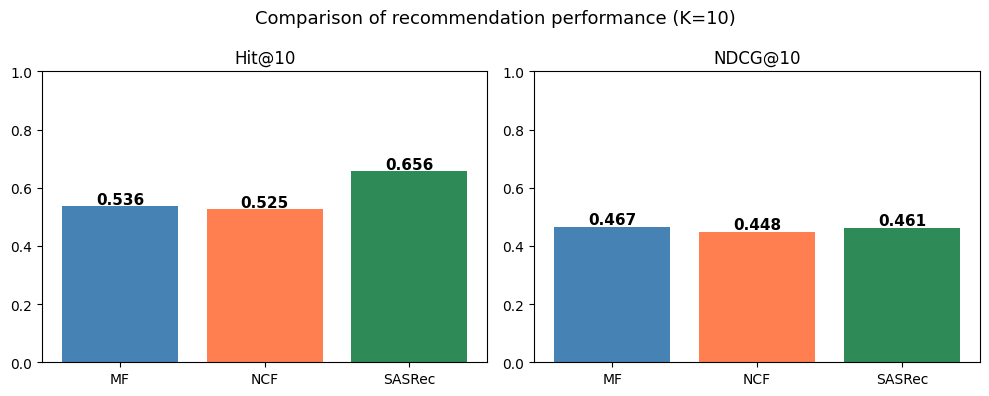

In [6]:
# 시각화
df_res = pd.DataFrame(results)
x = range(len(df_res))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['steelblue', 'coral', 'seagreen']
for ax, col, title in [
    (axes[0], 'hit@10',  'Hit@10'),
    (axes[1], 'ndcg@10', 'NDCG@10'),
]:
    bars = ax.bar(df_res['model'], df_res[col], color=colors)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    for bar, v in zip(bars, df_res[col]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Comparison of recommendation performance (K=10)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Attention 시각화 — 모델이 어디를 보는가

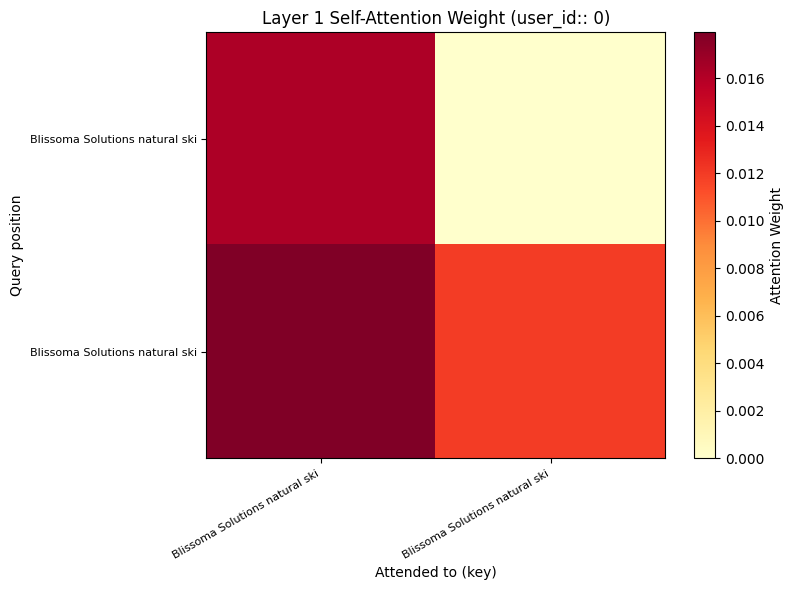

행=현재 위치, 열=참조 위치. 대각선=자기 자신, 밝을수록 높은 attention.


In [7]:
with open(DATA_DIR / 'item2id.json') as f:
    item2id = json.load(f)
id2item = {v: k for k, v in item2id.items()}
meta_df = pd.read_parquet(DATA_DIR / 'meta.parquet')[['parent_asin', 'title']].drop_duplicates('parent_asin')

def get_title(item_id_shifted):
    """SASRec item ID (1-indexed) → 상품명"""
    asin = id2item.get(item_id_shifted - 1, '')
    row = meta_df[meta_df['parent_asin'] == asin]
    return str(row['title'].values[0])[:30] if len(row) > 0 else f'item_{item_id_shifted}'

# 유저 0의 시퀀스로 attention weight 추출
user_id = 0
user_items = [i + 1 for i in train_df[train_df['user_id'] == user_id]
              .sort_values('timestamp')['parent_asin'].tolist()]

def pad(seq, length=MAX_LEN):
    seq = seq[-length:]
    return [0] * (length - len(seq)) + seq

seq_tensor = torch.tensor(pad(user_items), dtype=torch.long).unsqueeze(0)  # (1, L)

# 첫 번째 Transformer block의 attention weight 추출
attn_weights_all = []
def hook_fn(module, input, output):
    # output: (attn_output, attn_weights)
    attn_weights_all.append(output[1].detach())

hook = model.blocks[0].attn.register_forward_hook(hook_fn)
model.eval()
with torch.no_grad():
    _ = model.encode(seq_tensor)
hook.remove()

# 실제 아이템이 있는 마지막 N개 위치만 표시
n_show = min(6, len(user_items))
start_pos = MAX_LEN - n_show

attn = attn_weights_all[0][0, start_pos:, start_pos:].numpy()  # (n_show, n_show)
labels = [get_title(user_items[i]) for i in range(len(user_items) - n_show, len(user_items))]

plt.figure(figsize=(8, 6))
plt.imshow(attn, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Attention Weight')
plt.xticks(range(n_show), labels, rotation=30, ha='right', fontsize=8)
plt.yticks(range(n_show), labels, fontsize=8)
plt.title(f'Layer 1 Self-Attention Weight (user_id:: {user_id})')
plt.xlabel('Attended to (key)')
plt.ylabel('Query position')
plt.tight_layout()
plt.show()
print("행=현재 위치, 열=참조 위치. 대각선=자기 자신, 밝을수록 높은 attention.")

---
## 요약 — 세 모델 비교

| | MF | NCF | SASRec |
|-|-|-|-|
| 유저 표현 | 정적 벡터 1개 | 정적 벡터 1개 | 각 위치별 컨텍스트 |
| 순서 반영 | ✗ | ✗ | ✓ (Causal Attention) |
| 상호작용 | 선형 (내적) | 선형+비선형 | Attention + FFN |
| 유효 학습 신호 | 유저당 1개/배치 | 유저당 1개/배치 | 유저당 시퀀스 길이만큼 |

**SASRec이 개선되는 이유:**
1. 시퀀스의 **순서 정보**를 그대로 활용
2. 한 번의 forward에서 **여러 위치의 loss**를 동시에 계산 → 효율적 학습
3. Attention이 **최근의 관련 아이템에 집중**하는 패턴 학습

**다음 스텝**: LLM(Gemini) 큐레이션 모듈 구현  
SASRec의 Top-K 후보를 Gemini가 개인화 설명과 함께 재순위화합니다.